In [35]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

import plotly.graph_objs as go
import plotly.express as px
from plotly.figure_factory import create_scatterplotmatrix
from plotly.subplots import make_subplots

In [36]:
X_train = pd.read_csv("logReg_X_train_prepared.csv")
print(f"Shape of X_train {X_train.shape}")
X_test = pd.read_csv("logReg_X_test_prepared.csv")
print(f"Shape of X_test {X_test.shape}")
y_train = pd.read_csv("logReg_y_train_prepared.csv")
print(f"Shape of y_train {y_train.shape}")
y_test = pd.read_csv("logReg_y_test_prepared.csv")
print(f"Shape of y_test {y_test.shape}")

Shape of X_train (244, 10)
Shape of X_test (105, 10)
Shape of y_train (244, 1)
Shape of y_test (105, 1)


## Modell erstellen

In [37]:
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
logit_model=sm.Logit(y_train,X_train)

In [38]:
result=logit_model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.578886
         Iterations 6
                             Results: Logit
Model:                 Logit              Method:             MLE       
Dependent Variable:    Outcome Variable   Pseudo R-squared:   0.159     
Date:                  2025-05-05 18:26   AIC:                304.4962  
No. Observations:      244                BIC:                342.9651  
Df Model:              10                 Log-Likelihood:     -141.25   
Df Residuals:          233                LL-Null:            -167.95   
Converged:             1.0000             LLR p-value:        6.2878e-08
No. Iterations:        6.0000             Scale:              1.0000    
------------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------------
const                     1.5997   0.8390  1.9066 0

In [39]:
print(f"Anzahl pro binäre Variable im Train {y_train['Outcome Variable'].value_counts()/len(y_train)}")
print(f"Anzahl pro binäre Variable im Test {y_test['Outcome Variable'].value_counts()/len(y_test)}")

Anzahl pro binäre Variable im Train Outcome Variable
1    0.54918
0    0.45082
Name: count, dtype: float64
Anzahl pro binäre Variable im Test Outcome Variable
0    0.504762
1    0.495238
Name: count, dtype: float64


Hier werden die Werte vorausgesagt:

In [40]:
y_pred_train_proba = result.predict(X_train)
y_pred_test_proba = result.predict(X_test)

Bei der Überführung der berechneten Wahrscheinlichkeiten in die Kategorien 1 (Positiv) und 0 (Negativ) wird ein Schwellenwert von 0.3 angenommen. Dies aus dem Grund, dass es in medizinischen Diagnosen oft kritischer ist, falsch-negativ zu klassifizieren als falsch-positiv. 

<span style="color:yellow">Schwellenwert noch in der Gruppe besprechen</span> <br>
Schwellenwert bei 0.3:<br>
Accuracy Score for the training set: 0.6967213114754098<br>
Accuracy Score for the test set: 0.6285714285714286<br>
<br>
Precision score for the training set: 0.6530612244897959<br>
Precision score for the test set: 0.5764705882352941<br>
<br>
Recall score for the training set: 0.9552238805970149<br>
Recall score for the test set: 0.9423076923076923<br>
<br>
F1 score fot the training score: 0.7757575757575758<br>
F1 score fot the test score: 0.7153284671532847<br>
<br>
<br>
Schwellenwert bei 0.4:<br>
Accuracy Score for the training set: 0.7049180327868853<br>
Accuracy Score for the test set: 0.6285714285714286<br>
<br>
Precision score for the training set: 0.6802325581395349<br>
Precision score for the test set: 0.589041095890411<br>
<br>
Recall score for the training set: 0.8731343283582089<br>
Recall score for the test set: 0.8269230769230769<br>
<br>
F1 score fot the training score: 0.7647058823529411<br>
F1 score fot the test score: 0.688<br>
<br>
<br>
Schwellenwert bei 0.5:<br>
Accuracy Score for the training set: 0.6885245901639344<br>
Accuracy Score for the test set: 0.6761904761904762<br>
<br>
Precision score for the training set: 0.7101449275362319<br>
Precision score for the test set: 0.6451612903225806<br>
<br>
Recall score for the training set: 0.7313432835820896<br>
Recall score for the test set: 0.7692307692307693<br>
<br>
F1 score fot the training score: 0.7205882352941176<br>
F1 score fot the test score: 0.7017543859649122<br>

In [41]:
y_pred_train_class = (y_pred_train_proba>0.5).astype(int)
y_pred_test_class = (y_pred_test_proba>0.5).astype(int)

## Evaluation

### Konfusionsmatrix

Die Konfusionsmatrix des Training Sample ist:


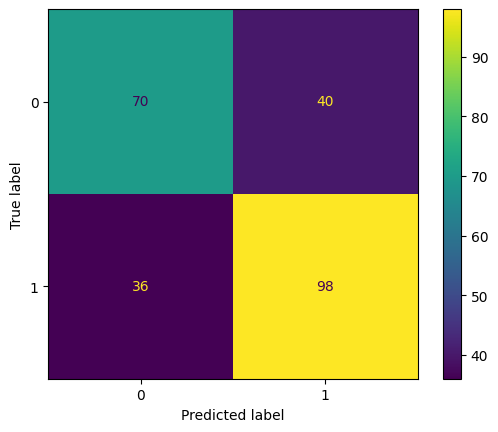

In [42]:
# Train Confusion Matrix
confusion_matrix_train = metrics.confusion_matrix(y_train, y_pred_train_class)
print(f"Die Konfusionsmatrix des Training Sample ist:")
metrics.ConfusionMatrixDisplay(confusion_matrix_train).plot()

Die Konfusionsmatrix des Training Sample ist:


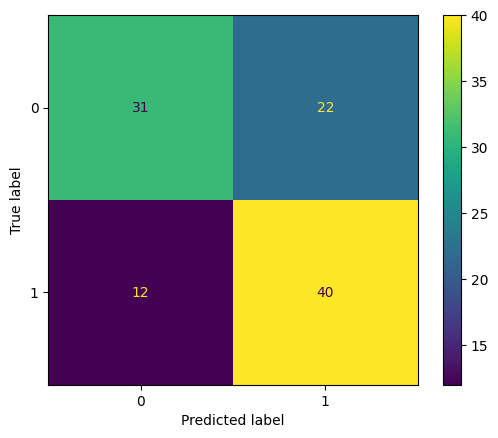

In [43]:
# Test Confusion Matrix
confusion_matrix_test = metrics.confusion_matrix(y_test, y_pred_test_class)
print(f"Die Konfusionsmatrix des Training Sample ist:")
metrics.ConfusionMatrixDisplay(confusion_matrix_test).plot()

### Accuracy-Score

In [44]:
print("Accuracy Score for the training set: {}".format(metrics.accuracy_score(y_train, y_pred_train_class)))
print("Accuracy Score for the test set: {}".format(metrics.accuracy_score(y_test, y_pred_test_class)))

Accuracy Score for the training set: 0.6885245901639344
Accuracy Score for the test set: 0.6761904761904762


### Precision und Recall

In [45]:
# Precision
print("Precision score for the training set: {}" .format(metrics.precision_score(y_train,y_pred_train_class)))
print("Precision score for the test set: {}" .format(metrics.precision_score(y_test,y_pred_test_class)))
# Recall
print("Recall score for the training set: {}".format(metrics.recall_score(y_train,y_pred_train_class)))
print("Recall score for the test set: {}".format(metrics.recall_score(y_test,y_pred_test_class)))

Precision score for the training set: 0.7101449275362319
Precision score for the test set: 0.6451612903225806
Recall score for the training set: 0.7313432835820896
Recall score for the test set: 0.7692307692307693


### F1-Score

In [46]:
print("F1 score fot the training score: {}" .format(metrics.f1_score(y_train, y_pred_train_class)))
print("F1 score fot the test score: {}" .format(metrics.f1_score(y_test, y_pred_test_class)))

F1 score fot the training score: 0.7205882352941176
F1 score fot the test score: 0.7017543859649122


### Area under the Curve (AOC)

In [47]:
# AUC for train
fpr, tpr, thresholds = metrics.roc_curve(y_train, y_pred_train_class)
print("AUC score for the training set: {}".format(metrics.auc(fpr, tpr)))
# AUC for test
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_test_class)
print("AUC score for the test set: {}".format(metrics.auc(fpr, tpr)))

AUC score for the training set: 0.683853459972863
AUC score for the test set: 0.6770682148040638
